In [1]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
data = pd.read_csv('../datasets/car_insurance_fraud.CSV')
y = data['fraud_reported'].replace({'Y': 1, 'N': 0}).astype(int)
X = data.drop(['fraud_reported'], axis=1)

# Turn date columns into numeric features.
policy_bind_date = pd.to_datetime(X['policy_bind_date'], dayfirst=True, errors='coerce')
incident_date = pd.to_datetime(X['incident_date'], dayfirst=True, errors='coerce')
X['policy_bind_year'] = policy_bind_date.dt.year
X['policy_bind_month'] = policy_bind_date.dt.month
X['policy_bind_day'] = policy_bind_date.dt.day
X['incident_year'] = incident_date.dt.year
X['incident_month'] = incident_date.dt.month
X['incident_day'] = incident_date.dt.day  
X['incident_dayofweek'] = incident_date.dt.dayofweek
X['days_between_bind_and_incident'] = (incident_date - policy_bind_date).dt.days

# Split composite coverage into two numeric columns.
policy_csl = X['policy_csl'].str.split('/', expand=True)
X['policy_csl_liability'] = pd.to_numeric(policy_csl[0], errors='coerce')
X['policy_csl_property'] = pd.to_numeric(policy_csl[1], errors='coerce')

# Encode binary and ordinal fields explicitly.
X['police_report_available'] = X['police_report_available'].replace({'YES': 1, 'NO': 0, '?': -1}).astype(int)
X['property_damage'] = X['property_damage'].replace({'YES': 1, 'NO': 0, '?': -1}).astype(int)
X['incident_severity'] = X['incident_severity'].replace({
    'Trivial Damage': 0,
    'Minor Damage': 1,
    'Major Damage': 2,
    'Total Loss': 3,
}).astype(int)

# Drop identifiers and high-cardinality text that are unlikely to help the model.
X = X.drop(columns=['policy_bind_date', 'incident_date', 'policy_csl', 'policy_number', 'insured_zip', 'incident_location', '_c39'])

# One-hot encode the remaining nominal categories.
X = pd.get_dummies(
    X,
    columns=[
        'policy_state',
        'insured_sex',
        'insured_education_level',
        'insured_occupation',
        'insured_hobbies',
        'insured_relationship',
        'incident_type',
        'collision_type',
        'authorities_contacted',
        'incident_state',
        'incident_city',
        'auto_make',
        'auto_model',
    ],
    dtype=int,
)

data

C:\Users\Anna\AppData\Local\Temp\ipykernel_24752\2040068139.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = data['fraud_reported'].replace({'Y': 1, 'N': 0}).astype(int)
C:\Users\Anna\AppData\Local\Temp\ipykernel_24752\2040068139.py:6: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  policy_bind_date = pd.to_datetime(X['policy_bind_date'], dayfirst=True, errors='coerce')
C:\Users\Anna\AppData\Local\Temp\ipykernel_24752\2040068139.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  incident_date = pd.to_datetime(X['incident_date'], dayfirst=True, errors

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


In [3]:
X = X.select_dtypes(include=[np.number]) #filter X to only include numeric columns
X = X.fillna(X.mean()) #fill NaN values with the mean of the column


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_train_means = X_train.mean().to_frame().T

COLUMNS = X_train.columns

nn = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        solver="adam",
        activation="tanh",
        hidden_layer_sizes=(1024, 512, 256),
        alpha=1e-5,
        learning_rate_init=3e-4,
        batch_size=32,
        early_stopping=False,
        max_iter=10000,
        random_state=0,
    ),
)
nn.fit(X_train, y_train)

def print_accuracy(f):
    print(
        "Accuracy = {0}%".format(
            100 *
            np.mean(
                f(X_test) == y_test))
    )
    time.sleep(0.5)  # to let the print get out before any progress bars

print_accuracy(nn.predict)

Accuracy = 78.0%


In [4]:
import pickle

with open('../datasets/car_insurance_fraud_nn.pkl', 'wb') as file:

    # A new file will be created
    pickle.dump(nn, file)

In [5]:
with open('../datasets/car_insurance_fraud_train.csv', 'wb') as file:
    
        # A new file will be created
        X_train.to_csv(file, index=False)

In [6]:
with open('../datasets/car_insurance_fraud_traintruth.csv', 'wb') as file:
    
    y_train.to_csv(file, index=False)

In [7]:
with open('../datasets/car_insurance_fraud_predict.csv', 'wb') as file:

    predictions = pd.DataFrame(nn.predict_proba(X_train), columns=[ 'Delete','Fraud_prediction'])
    predictions = predictions['Fraud_prediction']

    full = pd.concat([X_train.reset_index(drop=True), predictions], axis=1)

    full.to_csv(file, index=False)

In [8]:
import shap
prep = nn.named_steps["standardscaler"]
model = nn.named_steps["mlpclassifier"]
sampler = shap.sample(X_train, 100, random_state=0)
X_bg = prep.transform(sampler)
X_explain = prep.transform(X_test)

explainer = shap.KernelExplainer(model.predict, X_bg)

h:\Finch\venvReduced\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import shap
prep = nn.named_steps["standardscaler"]
model = nn.named_steps["mlpclassifier"]
sampler = shap.sample(X_train, 100, random_state=0)


def predict_with_prep(values):
    values_array = np.atleast_2d(values)
    values_df = pd.DataFrame(values_array, columns=sampler.columns)
    return model.predict(prep.transform(values_df))


explainer = shap.KernelExplainer(predict_with_prep, sampler)

In [10]:
import matplotlib.pyplot as plt

instance_values = {
    "months_as_customer": 155,
    "age": 39,
    "incident_severity": 2,
    "police_report_available": 0,
    "auto_make_Toyota": 1,
    "auto_make_Nissan": 0,
    "auto_make_Volkswagen": 0,
    "incident_dayofweek": 3,
}

# Create a duplicate of means and fill in the values of the example. 
example_means = sampler.mean().to_frame().T
for key, value in instance_values.items():
    if key in example_means:
        example_means[key] = value

# Shap values for the example
example_shap_values = explainer(example_means)
example_shap_explanation = shap.Explanation(
    values=example_shap_values.values[0],
    base_values=example_shap_values.base_values[0],
    data=example_means.iloc[0].values,
    feature_names=example_means.columns,
)

example_means

100%|██████████| 1/1 [00:06<00:00,  6.74s/it]


,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,capital-gains,capital-loss,incident_severity,incident_hour_of_the_day,number_of_vehicles_involved,...,auto_model_Pathfinder,auto_model_RAM,auto_model_RSX,auto_model_Silverado,auto_model_TL,auto_model_Tahoe,auto_model_Ultima,auto_model_Wrangler,auto_model_X5,auto_model_X6
0,155,39,1150.0,1307.6771,890000.0,27198.0,-24239.0,2,12.41,1.83,...,0.02,0.06,0.0,0.03,0.03,0.02,0.03,0.02,0.06,0.0


In [11]:
example_shap_explanation 

.values =
array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        , -0.03071121,  0.        ,  0.        ,
        0.        ,  0.        , -0.0270677 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        , -0.02575361,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -0.02840333, -0.02154954,  0.        ,  0.        ,
       -0.06214407, -0.02422009,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.     

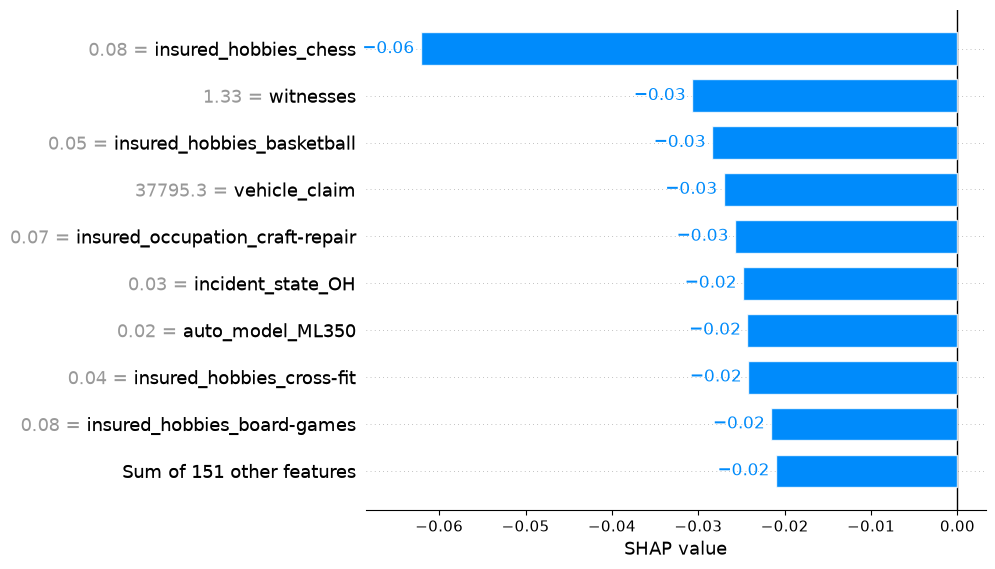

In [12]:
shap.plots.bar(example_shap_explanation)

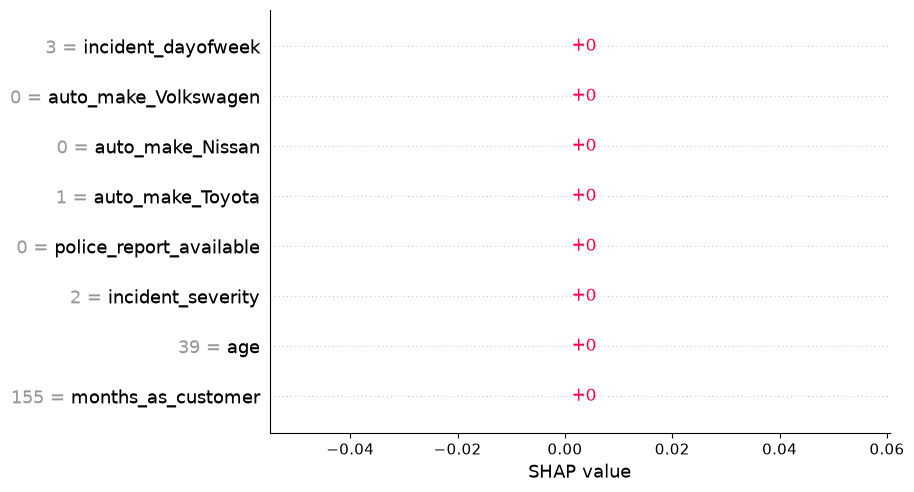

In [13]:
#Create a Shap bar plot that only displays the influence of the features that were user-defined. 
instance_indices = [example_shap_explanation.feature_names.index(feature) for feature in instance_values.keys() if feature in example_shap_explanation.feature_names]
shap.plots.bar(example_shap_explanation[instance_indices])

C:\Users\Anna\AppData\Local\Temp\ipykernel_24752\1877742325.py:21: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


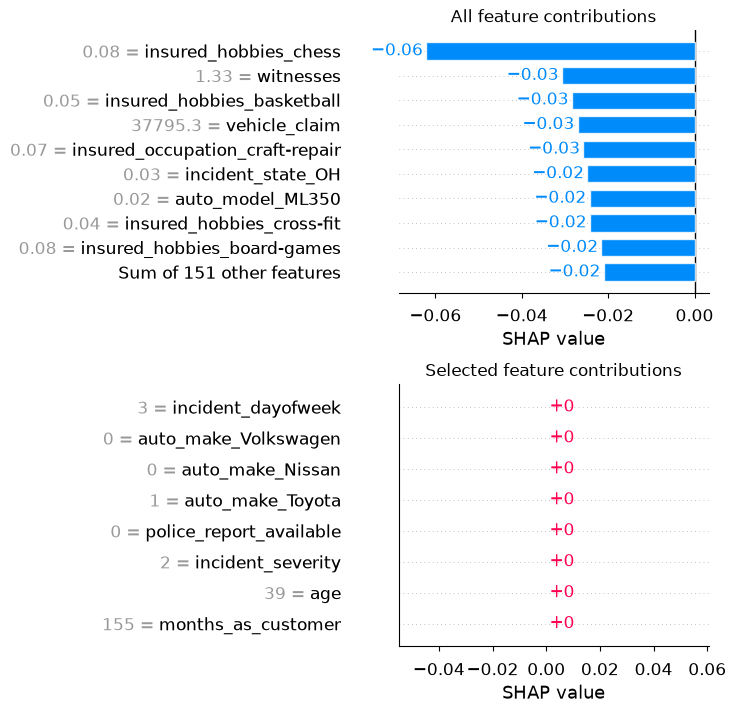

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(10, 40), gridspec_kw={"height_ratios": [3, 1]})

plt.sca(axs[0])
shap.plots.bar(example_shap_explanation, show=False)
axs[0].set_title("All feature contributions")

plt.sca(axs[1])
if len(instance_indices) > 0:
    shap.plots.bar(example_shap_explanation[instance_indices], show=False)
    axs[1].set_title("Selected feature contributions")
    fig.set_size_inches(4, 8)
    fig.subplots_adjust(hspace=0.35)
    for ax in axs:
        ax.tick_params(axis='y', labelsize=12, pad=38)
        ax.tick_params(axis='x', labelsize=12, pad=8)
else:
    axs[1].text(0.5, 0.5, "No selected features", ha="center", va="center")

plt.tight_layout()
plt.show()